# Recall-Aware Focal-Tversky Loss Ablation

This controlled experiment returns to the stronger baseline sampler and changes
only the loss function. The goal is to recover missed tumor pixels and patient
116 without recreating the balanced sampler's false-positive burden.

Dataset, split, preprocessing, architecture, initialization, augmentation,
sampler, optimizer, learning-rate schedule and validation protocol remain fixed.
The test split remains locked.


## tl;dr

The balanced sampler doubled smallest-lesion detection from **25.5% to 54.0%**,
but mean patient Dice fell from **0.3831 to 0.3562** and empty-slice false
positives rose from **3.35% to 17.83%**.

This fresh 10-epoch experiment restores the baseline `3x` positive-slice sampler
and replaces Focal-Dice with a moderately recall-aware Focal-Tversky loss:

- false-positive penalty `alpha = 0.40`
- false-negative penalty `beta = 0.60`
- focal exponent `gamma = 0.75`

Run all cells once with the project `.venv` kernel.


## Context & Methods

### Key assumptions

- The manifest, verified loader, tumor masks, orientation and splits are frozen.
- Sampling uses the original baseline `3x` positive-slice weight.
- Validation patients never influence training or checkpoint selection beyond
  the already-defined mean-patient-Dice criterion.
- A fresh model provides a fair loss comparison.

### Single intervention

Focal-Tversky penalizes false negatives more strongly than false positives,
using a moderate `0.60 / 0.40` asymmetry. This is intentionally less aggressive
than the failed balanced sampler. Promotion still requires false positives below
15%.


In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import math
import platform
import random
import subprocess
import sys
import time
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
SMOKE_PER_SLICE = (
    PROJECT_ROOT / "Practice" / "manifest_baseline_smoke_outputs"
    / "baseline_smoke_per_slice.csv"
)
BASELINE_OUTPUT_DIR = PROJECT_ROOT / "Practice" / "patient_aware_baseline_outputs"
SAMPLER_OUTPUT_DIR = PROJECT_ROOT / "Practice" / "patient_lesion_balanced_outputs"
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "recall_aware_loss_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
RUN_TRAINING = True
RESUME_IF_AVAILABLE = True
EPOCHS = 25
MIN_EPOCHS_BEFORE_EARLY_STOP = 10
EARLY_STOPPING_PATIENCE = 6
EARLY_STOPPING_MIN_DELTA = 0.001
BATCH_SIZE = 8
VALIDATION_BATCH_SIZE = 16
LEARNING_RATE = 3e-4
MIN_LEARNING_RATE = 3e-6
WEIGHT_DECAY = 1e-4
SAMPLER_STRATEGY = "positive_slice_weight_3_baseline"
LOSS_STRATEGY = "focal_tversky_a040_b060_g075"
POSITIVE_SAMPLE_WEIGHT = 3.0
TVERSKY_ALPHA = 0.40
TVERSKY_BETA = 0.60
FOCAL_TVERSKY_GAMMA = 0.75
FIXED_THRESHOLD = 0.50
THRESHOLDS = np.arange(0.30, 0.91, 0.05).round(2)
USE_MIXED_PRECISION = True
USE_PRETRAINED_ENCODER = False
NUM_WORKERS = 0
TARGET_DECISION_EPOCH = 10
MAX_START_GPU_TEMP_C = 84
COOLDOWN_WARNING_TEMP_C = 88
EMERGENCY_STOP_TEMP_C = 90
COOLDOWN_POLL_SECONDS = 30
MAX_COOLDOWN_MINUTES = 30
EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__}")
print(f"OS: {platform.platform()} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Outputs: {OUTPUT_DIR}")

Python 3.11.15 | PyTorch 2.6.0+cu124
OS: Windows-10-10.0.26200-SP0 | CUDA: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\recall_aware_loss_outputs


## Process Visualization

### Thermal-safe continuation workflow

This diagram shows what is restored, what runs during each short session, and
which evidence is required before a model decision.

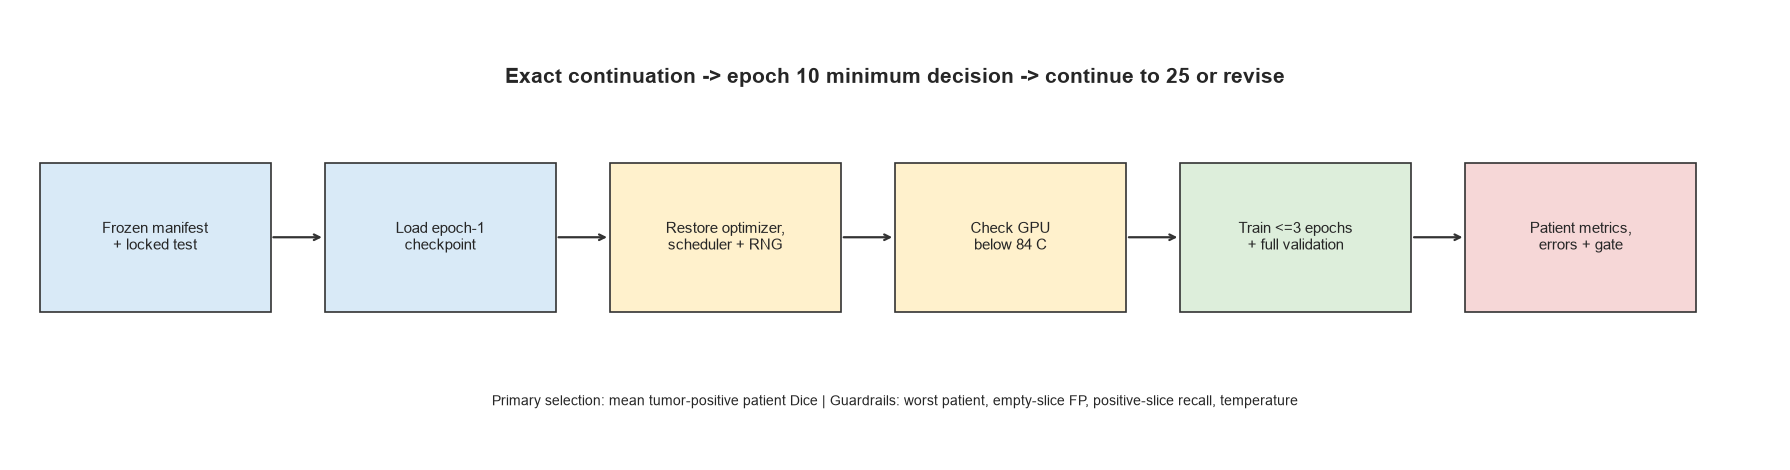

In [2]:

fig, axis = plt.subplots(figsize=(18, 4.8))
axis.set_xlim(0, 18)
axis.set_ylim(0, 5)
axis.axis("off")

steps = [
    (0.3, "Frozen manifest\n+ locked test", "#D9EAF7"),
    (3.2, "Load epoch-1\ncheckpoint", "#D9EAF7"),
    (6.1, "Restore optimizer,\nscheduler + RNG", "#FFF1CC"),
    (9.0, "Check GPU\nbelow 84 C", "#FFF1CC"),
    (11.9, "Train <=3 epochs\n+ full validation", "#DDEEDB"),
    (14.8, "Patient metrics,\nerrors + gate", "#F6D7D7"),
]
for x, label, color in steps:
    patch = plt.Rectangle(
        (x, 1.65), 2.35, 1.65, facecolor=color,
        edgecolor="#333333", linewidth=1.2
    )
    axis.add_patch(patch)
    axis.text(x + 1.175, 2.475, label, ha="center", va="center", fontsize=11)
for (left, _, _), (right, _, _) in zip(steps[:-1], steps[1:]):
    axis.annotate(
        "", xy=(right, 2.475), xytext=(left + 2.35, 2.475),
        arrowprops={"arrowstyle": "->", "linewidth": 1.6, "color": "#333333"},
    )
axis.text(
    9, 4.25,
    "Exact continuation -> epoch 10 minimum decision -> continue to 25 or revise",
    ha="center", va="center", fontsize=15, weight="bold",
)
axis.text(
    9, 0.65,
    "Primary selection: mean tumor-positive patient Dice | "
    "Guardrails: worst patient, empty-slice FP, positive-slice recall, temperature",
    ha="center", va="center", fontsize=10,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "continuation_process_map.png", dpi=160, bbox_inches="tight")
plt.show()


## Data

The same verified manifest and natural validation loader are used. The training
sampler is restored exactly to the baseline protocol: tumor-positive slices
receive weight `3`, and empty slices receive weight `1`.


In [3]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


manifest_hash = sha256_file(MANIFEST_PATH)
assert manifest_hash == EXPECTED_MANIFEST_SHA256
manifest = pd.read_csv(MANIFEST_PATH)
assert len(manifest) == 58_638
assert manifest["sample_id"].is_unique
assert manifest["verification_status"].eq("verified").all()
assert manifest["manual_spatial_status"].eq("approved").all()

try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError as exc:
    print(f"PASS: test split locked: {exc}")
else:
    raise AssertionError("Test split opened without explicit authorization.")

volume_sets = {
    split: set(manifest.loc[manifest["split"].eq(split), "volume_id"])
    for split in ("train", "val", "test")
}
assert volume_sets["train"].isdisjoint(volume_sets["val"])
assert volume_sets["train"].isdisjoint(volume_sets["test"])
assert volume_sets["val"].isdisjoint(volume_sets["test"])
print(f"PASS: frozen manifest {manifest_hash[:12]}... and patient isolation verified.")

PASS: test split locked: Test data access is locked. Pass allow_test=True only for the one-time held-out evaluation after model decisions are frozen.
PASS: frozen manifest 575a6fc391d6... and patient isolation verified.


### 2. Define paired training augmentation

The transform uses bilinear interpolation for images and nearest-neighbour interpolation for masks. Validation receives no transform.

In [4]:
class PairedTrainingAugment:
    def __init__(
        self,
        flip_probability=0.30,
        affine_probability=0.60,
        max_rotation_degrees=10.0,
        max_translation_fraction=0.05,
        scale_range=(0.95, 1.05),
        intensity_probability=0.50,
        brightness_shift=0.05,
        contrast_range=(0.90, 1.10),
    ):
        self.flip_probability = flip_probability
        self.affine_probability = affine_probability
        self.max_rotation_degrees = max_rotation_degrees
        self.max_translation_fraction = max_translation_fraction
        self.scale_range = scale_range
        self.intensity_probability = intensity_probability
        self.brightness_shift = brightness_shift
        self.contrast_range = contrast_range

    def __call__(self, image: np.ndarray, mask: np.ndarray):
        image = np.asarray(image, dtype=np.float32)
        mask = np.asarray(mask, dtype=np.float32)

        if random.random() < self.flip_probability:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()

        if random.random() < self.affine_probability:
            height, width = image.shape
            angle = random.uniform(-self.max_rotation_degrees, self.max_rotation_degrees)
            scale = random.uniform(*self.scale_range)
            tx = random.uniform(-self.max_translation_fraction, self.max_translation_fraction) * width
            ty = random.uniform(-self.max_translation_fraction, self.max_translation_fraction) * height
            matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, scale)
            matrix[:, 2] += (tx, ty)
            image = cv2.warpAffine(
                image, matrix, (width, height), flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_CONSTANT, borderValue=0,
            )
            mask = cv2.warpAffine(
                mask, matrix, (width, height), flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_CONSTANT, borderValue=0,
            )

        if random.random() < self.intensity_probability:
            contrast = random.uniform(*self.contrast_range)
            brightness = random.uniform(-self.brightness_shift, self.brightness_shift)
            image = np.clip(image * contrast + brightness, 0.0, 1.0)

        mask = (mask > 0.5).astype(np.float32)
        return np.ascontiguousarray(image), np.ascontiguousarray(mask)


train_transform = PairedTrainingAugment()

### 3. Restore the baseline weighted training sampler

In [5]:
train_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="train", root_dir=DATASET_ROOT,
    target="tumor", transform=train_transform, validate_paths=True,
)
val_dataset = VerifiedManifestDataset(
    MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
    target="tumor", transform=None, validate_paths=True,
)

train_flags = np.asarray(train_dataset.tumor_positive_flags, dtype=bool)
weights = np.where(train_flags, POSITIVE_SAMPLE_WEIGHT, 1.0)
sampler_generator = torch.Generator().manual_seed(SEED)
train_sampler = WeightedRandomSampler(
    torch.as_tensor(weights, dtype=torch.double),
    num_samples=len(train_dataset), replacement=True,
    generator=sampler_generator,
)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_dataset, batch_size=VALIDATION_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available(),
)

natural_rate = float(train_flags.mean())
expected_rate = (
    POSITIVE_SAMPLE_WEIGHT * natural_rate
    / (POSITIVE_SAMPLE_WEIGHT * natural_rate + 1 - natural_rate)
)
preview_indices = np.asarray(list(iter(train_sampler))[: min(12000, len(train_dataset))])
preview_rate = float(train_flags[preview_indices].mean())
sampling_audit = pd.DataFrame({
    "measure": ["Natural training", "Expected weighted", "Sampler preview"],
    "positive_slice_pct": [100 * natural_rate, 100 * expected_rate, 100 * preview_rate],
})
display(sampling_audit.style.format({"positive_slice_pct": "{:.2f}%"}))
print(f"Train={len(train_dataset):,} | Validation={len(val_dataset):,}")


,measure,positive_slice_pct
0,Natural training,12.12%
1,Expected weighted,29.27%
2,Sampler preview,29.23%


Train=40,667 | Validation=10,685


### 4. Verify the restored sampler and paired augmentation

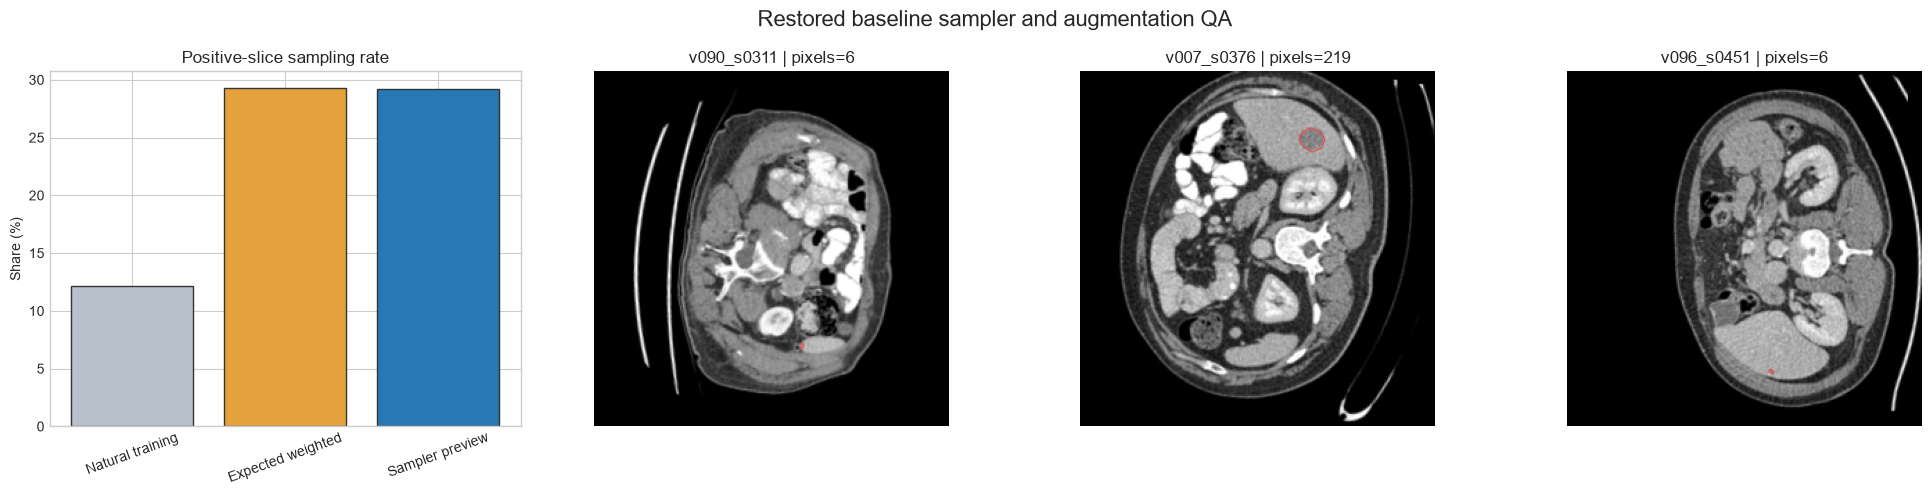

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].bar(
    sampling_audit["measure"], sampling_audit["positive_slice_pct"],
    color=["#B9C2CC", "#E6A23C", "#2878B5"], edgecolor="#333333",
)
axes[0].set_title("Positive-slice sampling rate")
axes[0].set_ylabel("Share (%)")
axes[0].tick_params(axis="x", rotation=20)

positive_indices = np.flatnonzero(train_flags)
preview_source_indices = np.random.default_rng(SEED).choice(
    positive_indices, size=min(3, len(positive_indices)), replace=False
)
for axis, source_index in zip(axes[1:], preview_source_indices):
    sample = train_dataset[int(source_index)]
    image = sample["image"][0].numpy()
    mask = sample["mask"][0].numpy()
    axis.imshow(image, cmap="gray")
    axis.contour(mask, levels=[0.5], colors=["#E15759"], linewidths=1.0)
    axis.set_title(f"{sample['sample_id']} | pixels={int(mask.sum()):,}")
    axis.axis("off")

fig.suptitle("Restored baseline sampler and augmentation QA", fontsize=16)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sampler_and_augmentation_audit.png", dpi=160, bbox_inches="tight")
plt.show()


## Results

### 5. Define patient-aware evaluation and exact-resume utilities

In [7]:
import torch.nn as nn

class FocalTverskyLoss(nn.Module):
    """Batch-mean focal Tversky loss with explicit FP/FN penalties."""
    def __init__(self, alpha=0.40, beta=0.60, gamma=0.75, smooth=1.0):
        super().__init__()
        if not math.isclose(alpha + beta, 1.0, abs_tol=1e-8):
            raise ValueError("Tversky alpha and beta must sum to 1.")
        self.alpha, self.beta = alpha, beta
        self.gamma, self.smooth = gamma, smooth

    def forward(self, logits, targets):
        # Accumulate overlap terms in float32 even under AMP. Fractional
        # powers of a tiny negative value caused by fp16 rounding produce NaN.
        probabilities = torch.sigmoid(logits.float())
        targets = targets.float()
        dimensions = tuple(range(1, logits.ndim))
        true_positive = (probabilities * targets).sum(dim=dimensions)
        false_positive = (probabilities * (1.0 - targets)).sum(dim=dimensions)
        false_negative = ((1.0 - probabilities) * targets).sum(dim=dimensions)
        score = (true_positive + self.smooth) / (
            true_positive + self.alpha * false_positive
            + self.beta * false_negative + self.smooth
        )
        score = score.clamp(min=0.0, max=1.0)
        focal_error = (1.0 - score).clamp(min=0.0, max=1.0)
        return torch.pow(focal_error, self.gamma).mean()

from src.framework.models.mobilenetv2_unet import MobileNetV2UNet


def gpu_stats():
    if not torch.cuda.is_available():
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}
    try:
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=temperature.gpu,utilization.gpu,memory.used",
             "--format=csv,noheader,nounits"],
            capture_output=True, text=True, check=True,
        )
        values = [float(value.strip()) for value in result.stdout.splitlines()[0].split(",")]
        return {"temperature_c": values[0], "utilization_pct": values[1], "memory_mb": values[2]}
    except Exception:
        return {"temperature_c": np.nan, "utilization_pct": np.nan, "memory_mb": np.nan}



def append_thermal_log(record: dict):
    path = OUTPUT_DIR / "thermal_cooldown_log.csv"
    frame = pd.DataFrame([record])
    if path.is_file():
        existing = pd.read_csv(path)
        frame = pd.concat([existing, frame], ignore_index=True)
    frame.to_csv(path, index=False)


def wait_for_gpu_cool(epoch: int) -> bool:
    """Wait in bounded 30-second checks until the next epoch is thermally safe."""
    if not torch.cuda.is_available():
        return True
    started_wait = time.time()
    max_wait_seconds = MAX_COOLDOWN_MINUTES * 60
    while True:
        thermal = gpu_stats()
        elapsed = time.time() - started_wait
        append_thermal_log({
            "timestamp": pd.Timestamp.now().isoformat(),
            "target_epoch": int(epoch),
            "temperature_c": thermal["temperature_c"],
            "utilization_pct": thermal["utilization_pct"],
            "memory_mb": thermal["memory_mb"],
            "cooldown_elapsed_seconds": elapsed,
        })
        temperature = thermal["temperature_c"]
        if not np.isfinite(temperature) or temperature < MAX_START_GPU_TEMP_C:
            print(
                f"READY: epoch {epoch} starts at "
                f"{temperature:.0f}C." if np.isfinite(temperature)
                else f"READY: epoch {epoch}; temperature unavailable."
            )
            return True
        if elapsed >= max_wait_seconds:
            return False
        print(
            f"COOLING: GPU {temperature:.0f}C; waiting "
            f"{COOLDOWN_POLL_SECONDS}s before epoch {epoch}."
        )
        time.sleep(COOLDOWN_POLL_SECONDS)

def evaluate_patient_aware(model, loader, criterion, device, threshold=0.5, collect_rows=False):
    model.eval()
    loss_sum = intersection = predicted = actual = 0.0
    positive_seen = positive_detected = positive_empty = 0
    empty_seen = empty_with_fp = 0
    patient = {}
    rows = []
    with torch.inference_mode():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = probabilities >= threshold
            truth = masks >= 0.5
            loss_sum += float(criterion(logits, masks)) * images.shape[0]
            intersection += float((predictions & truth).sum())
            predicted += float(predictions.sum())
            actual += float(truth.sum())

            for index, sample_id in enumerate(batch["sample_id"]):
                volume_id = int(batch["volume_id"][index])
                true_px = int(truth[index].sum())
                pred_px = int(predictions[index].sum())
                inter_px = int((predictions[index] & truth[index]).sum())
                dice = (2 * inter_px + 1e-6) / (pred_px + true_px + 1e-6)
                accumulator = patient.setdefault(
                    volume_id, {"intersection": 0, "predicted": 0, "true": 0,
                                "positive_slices": 0, "detected": 0, "positive_empty": 0,
                                "empty_slices": 0, "empty_with_fp": 0}
                )
                accumulator["intersection"] += inter_px
                accumulator["predicted"] += pred_px
                accumulator["true"] += true_px
                if true_px > 0:
                    positive_seen += 1
                    positive_detected += int(inter_px > 0)
                    positive_empty += int(pred_px == 0)
                    accumulator["positive_slices"] += 1
                    accumulator["detected"] += int(inter_px > 0)
                    accumulator["positive_empty"] += int(pred_px == 0)
                else:
                    empty_seen += 1
                    empty_with_fp += int(pred_px > 0)
                    accumulator["empty_slices"] += 1
                    accumulator["empty_with_fp"] += int(pred_px > 0)
                if collect_rows:
                    rows.append({
                        "sample_id": sample_id, "volume_id": volume_id,
                        "slice_index": int(batch["slice_index"][index]),
                        "true_pixels": true_px, "predicted_pixels": pred_px,
                        "intersection_pixels": inter_px, "dice": dice,
                        "mean_probability": float(probabilities[index].mean()),
                        "max_probability": float(probabilities[index].max()),
                    })

    patient_rows = []
    for volume_id, values in sorted(patient.items()):
        denominator = values["predicted"] + values["true"]
        patient_rows.append({
            "volume_id": volume_id,
            "micro_dice": (
                (2 * values["intersection"] + 1e-6) / (denominator + 1e-6)
            ),
            "true_pixels": values["true"],
            "predicted_pixels": values["predicted"],
            "positive_slices": values["positive_slices"],
            "positive_slice_recall": values["detected"] / max(values["positive_slices"], 1),
            "positive_predicted_empty_pct": 100 * values["positive_empty"] / max(values["positive_slices"], 1),
            "empty_slice_false_positive_pct": 100 * values["empty_with_fp"] / max(values["empty_slices"], 1),
        })
    patient_frame = pd.DataFrame(patient_rows)
    tumor_positive_patients = patient_frame.loc[patient_frame["true_pixels"].gt(0)]
    return {
        "loss": loss_sum / len(loader.dataset),
        "global_micro_dice": float((2 * intersection + 1e-6) / (predicted + actual + 1e-6)),
        "pixel_precision": float((intersection + 1e-6) / (predicted + 1e-6)),
        "pixel_recall": float((intersection + 1e-6) / (actual + 1e-6)),
        "positive_slice_recall": positive_detected / max(positive_seen, 1),
        "positive_predicted_empty_pct": 100 * positive_empty / max(positive_seen, 1),
        "empty_slice_false_positive_pct": 100 * empty_with_fp / max(empty_seen, 1),
        "mean_patient_dice": float(tumor_positive_patients["micro_dice"].mean()),
        "median_patient_dice": float(tumor_positive_patients["micro_dice"].median()),
        "worst_patient_dice": float(tumor_positive_patients["micro_dice"].min()),
        "predicted_pixels": int(predicted), "true_pixels": int(actual),
        "patient_rows": patient_rows, "rows": rows,
    }


def capture_rng_state():
    return {
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "cuda_rng_state_all": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "sampler_generator_state": sampler_generator.get_state(),
    }


def restore_rng_state(payload):
    random.setstate(payload["python_random_state"])
    np.random.set_state(payload["numpy_random_state"])
    torch.set_rng_state(payload["torch_rng_state"].detach().cpu().to(torch.uint8))
    if torch.cuda.is_available() and payload.get("cuda_rng_state_all") is not None:
        torch.cuda.set_rng_state_all([
            state.detach().cpu().to(torch.uint8)
            for state in payload["cuda_rng_state_all"]
        ])
    sampler_generator.set_state(
        payload["sampler_generator_state"].detach().cpu().to(torch.uint8)
    )


def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, history, patient_history, best_score, stale_epochs):
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "epoch": int(epoch), "history": history,
        "patient_history": patient_history,
        "best_mean_patient_dice": float(best_score),
        "stale_epochs": int(stale_epochs),
        "rng_state": capture_rng_state(),
        "manifest_sha256": manifest_hash,
        "configuration": {
            "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
            "sampler_strategy": SAMPLER_STRATEGY,
        "loss_strategy": LOSS_STRATEGY,
            "fixed_threshold": FIXED_THRESHOLD,
        },
    }, path)

### 6. Train, validate, checkpoint, cool, and resume

The cell pauses when temperature is at or above the limit. Rerun this cell after cooling.

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = bool(USE_MIXED_PRECISION and device.type == "cuda")
model = MobileNetV2UNet(
    in_channels=1, out_channels=1, pretrained=USE_PRETRAINED_ENCODER
).to(device)
criterion = FocalTverskyLoss(
    alpha=TVERSKY_ALPHA, beta=TVERSKY_BETA,
    gamma=FOCAL_TVERSKY_GAMMA,
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=MIN_LEARNING_RATE
)
scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

last_checkpoint = OUTPUT_DIR / "patient_aware_last.pth"
best_checkpoint = OUTPUT_DIR / "patient_aware_best.pth"
history, patient_history = [], []
start_epoch, stale_epochs = 1, 0
best_mean_patient_dice = -1.0

if RESUME_IF_AVAILABLE and last_checkpoint.is_file():
    checkpoint = torch.load(last_checkpoint, map_location=device, weights_only=False)
    if checkpoint.get("manifest_sha256") != manifest_hash:
        raise RuntimeError("Checkpoint manifest differs from the frozen dataset.")
    expected_configuration = {
        "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
        "sampler_strategy": SAMPLER_STRATEGY,
        "loss_strategy": LOSS_STRATEGY,
        "fixed_threshold": FIXED_THRESHOLD,
    }
    if checkpoint.get("configuration") != expected_configuration:
        raise RuntimeError(
            "Existing checkpoint configuration differs from this notebook. "
            "Use a new output directory for a changed experiment."
        )
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    scaler.load_state_dict(checkpoint.get("scaler_state", {}))
    history = list(checkpoint.get("history", []))
    patient_history = list(checkpoint.get("patient_history", []))
    best_mean_patient_dice = float(checkpoint.get("best_mean_patient_dice", -1))
    stale_epochs = int(checkpoint.get("stale_epochs", 0))
    start_epoch = int(checkpoint["epoch"]) + 1
    restore_rng_state(checkpoint["rng_state"])
    print(f"Resuming exactly at epoch {start_epoch}; best patient Dice={best_mean_patient_dice:.4f}.")

stop_reason = "not_started"
if RUN_TRAINING and start_epoch <= EPOCHS:
    started = time.perf_counter()
    try:
        session_end_epoch = min(EPOCHS, TARGET_DECISION_EPOCH)
        for epoch in range(start_epoch, session_end_epoch + 1):
            cooled = wait_for_gpu_cool(epoch)
            if not cooled:
                stop_reason = 'cooldown_timeout'
                print(
                    f'WAIT: GPU did not cool below {MAX_START_GPU_TEMP_C}C within '
                    f'{MAX_COOLDOWN_MINUTES} minutes. Check ventilation and rerun later.'
                )
                break
            model.train()
            train_loss_sum = 0.0
            for batch in train_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks = batch["mask"].to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    logits = model(images)
                    loss = criterion(logits, masks)
                if not torch.isfinite(loss):
                    raise FloatingPointError(f"Non-finite loss at epoch {epoch}.")
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()
                train_loss_sum += float(loss.detach()) * images.shape[0]

            validation = evaluate_patient_aware(
                model, val_loader, criterion, device, FIXED_THRESHOLD
            )
            thermal = gpu_stats()
            record = {
                "epoch": epoch,
                "train_loss": train_loss_sum / len(train_dataset),
                "val_loss": validation["loss"],
                "val_global_micro_dice": validation["global_micro_dice"],
                "val_mean_patient_dice": validation["mean_patient_dice"],
                "val_median_patient_dice": validation["median_patient_dice"],
                "val_worst_patient_dice": validation["worst_patient_dice"],
                "val_pixel_precision": validation["pixel_precision"],
                "val_pixel_recall": validation["pixel_recall"],
                "val_positive_slice_recall": validation["positive_slice_recall"],
                "val_positive_predicted_empty_pct": validation["positive_predicted_empty_pct"],
                "val_empty_slice_false_positive_pct": validation["empty_slice_false_positive_pct"],
                "lr": optimizer.param_groups[0]["lr"], **thermal,
                "elapsed_seconds": time.perf_counter() - started,
            }
            history.append(record)
            for patient_row in validation["patient_rows"]:
                patient_history.append({"epoch": epoch, **patient_row})

            improved = validation["mean_patient_dice"] > (
                best_mean_patient_dice + EARLY_STOPPING_MIN_DELTA
            )
            if improved:
                best_mean_patient_dice = validation["mean_patient_dice"]
                stale_epochs = 0
            else:
                stale_epochs += 1
            scheduler.step()

            pd.DataFrame(history).to_csv(OUTPUT_DIR / "patient_aware_history.csv", index=False)
            pd.DataFrame(patient_history).to_csv(OUTPUT_DIR / "patient_metrics_by_epoch.csv", index=False)
            save_checkpoint(
                last_checkpoint, model, optimizer, scheduler, scaler, epoch,
                history, patient_history, best_mean_patient_dice, stale_epochs,
            )
            if improved:
                save_checkpoint(
                    best_checkpoint, model, optimizer, scheduler, scaler, epoch,
                    history, patient_history, best_mean_patient_dice, stale_epochs,
                )

            print(
                f"epoch={epoch:02d} train={record['train_loss']:.4f} "
                f"val={record['val_loss']:.4f} global={record['val_global_micro_dice']:.4f} "
                f"patient_mean={record['val_mean_patient_dice']:.4f} "
                f"worst={record['val_worst_patient_dice']:.4f} "
                f"temp={thermal['temperature_c']:.0f}C"
            )

            if np.isfinite(thermal["temperature_c"]) and thermal["temperature_c"] >= EMERGENCY_STOP_TEMP_C:
                stop_reason = "emergency_thermal_stop"
                print(
                    f"STOP: GPU reached {thermal['temperature_c']:.0f}C. "
                    "The completed epoch is saved; inspect cooling before resuming."
                )
                break
            if np.isfinite(thermal["temperature_c"]) and thermal["temperature_c"] >= COOLDOWN_WARNING_TEMP_C:
                print(
                    f"COOLDOWN: GPU reached {thermal['temperature_c']:.0f}C. "
                    "The next epoch will wait for a safe start temperature."
                )
            if (
                epoch >= MIN_EPOCHS_BEFORE_EARLY_STOP
                and stale_epochs >= EARLY_STOPPING_PATIENCE
            ):
                stop_reason = "early_stopping"
                print("STOP: patient-level validation metric stopped improving.")
                break
        else:
            stop_reason = (
                'completed_25_epochs'
                if session_end_epoch >= EPOCHS
                else 'epoch_10_decision_point_reached'
            )
    except KeyboardInterrupt:
        stop_reason = "interrupted_safely"
        print("Interrupted safely; the last completed epoch is preserved.")
elif start_epoch > EPOCHS:
    stop_reason = "already_completed"
else:
    stop_reason = "training_disabled"

history_frame = pd.read_csv(OUTPUT_DIR / "patient_aware_history.csv") if (
    OUTPUT_DIR / "patient_aware_history.csv"
).is_file() else pd.DataFrame()
patient_history_frame = pd.read_csv(OUTPUT_DIR / "patient_metrics_by_epoch.csv") if (
    OUTPUT_DIR / "patient_metrics_by_epoch.csv"
).is_file() else pd.DataFrame()
display(history_frame.tail(10))
print(f"Stop reason: {stop_reason}")

Resuming exactly at epoch 7; best patient Dice=0.0000.
READY: epoch 7 starts at 61C.
epoch=07 train=0.2843 val=0.0948 global=0.0000 patient_mean=0.0000 worst=0.0000 temp=87C
COOLING: GPU 85C; waiting 30s before epoch 8.
READY: epoch 8 starts at 73C.
epoch=08 train=0.2854 val=0.0948 global=0.0000 patient_mean=0.0000 worst=0.0000 temp=86C
COOLING: GPU 86C; waiting 30s before epoch 9.
READY: epoch 9 starts at 73C.
epoch=09 train=0.2863 val=0.0949 global=0.0000 patient_mean=0.0000 worst=0.0000 temp=86C
COOLING: GPU 86C; waiting 30s before epoch 10.
READY: epoch 10 starts at 73C.
epoch=10 train=0.2847 val=0.0948 global=0.0000 patient_mean=0.0000 worst=0.0000 temp=87C
STOP: patient-level validation metric stopped improving.


,epoch,train_loss,val_loss,val_global_micro_dice,val_mean_patient_dice,val_median_patient_dice,val_worst_patient_dice,val_pixel_precision,val_pixel_recall,val_positive_slice_recall,val_positive_predicted_empty_pct,val_empty_slice_false_positive_pct,lr,temperature_c,utilization_pct,memory_mb,elapsed_seconds
0,1,0.687361,0.096843,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000300,86.0,82.0,391.0,484.355205
1,2,0.283697,0.099245,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000299,87.0,52.0,961.0,1045.520655
2,3,0.286486,0.094836,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000295,86.0,47.0,961.0,1561.482546
3,4,0.286479,0.094836,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000290,86.0,74.0,961.0,2079.551946
4,5,0.286859,0.094755,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000282,87.0,63.0,961.0,2596.593514
5,6,0.285345,0.094751,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000272,87.0,53.0,961.0,3111.976808
6,7,0.284290,0.094759,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000260,87.0,57.0,423.0,516.525443
7,8,0.285407,0.094805,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000246,86.0,73.0,991.0,1052.657005
8,9,0.286296,0.094857,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000231,86.0,69.0,991.0,1586.092042
9,10,0.284657,0.094780,1.516330e-12,5.303859e-10,4.744733e-11,2.749534e-12,1.0,1.516330e-12,0.0,100.0,0.0,0.000215,87.0,58.0,991.0,2133.997233


Stop reason: early_stopping


### 7. Visualize learning, patient robustness, detection, and temperature

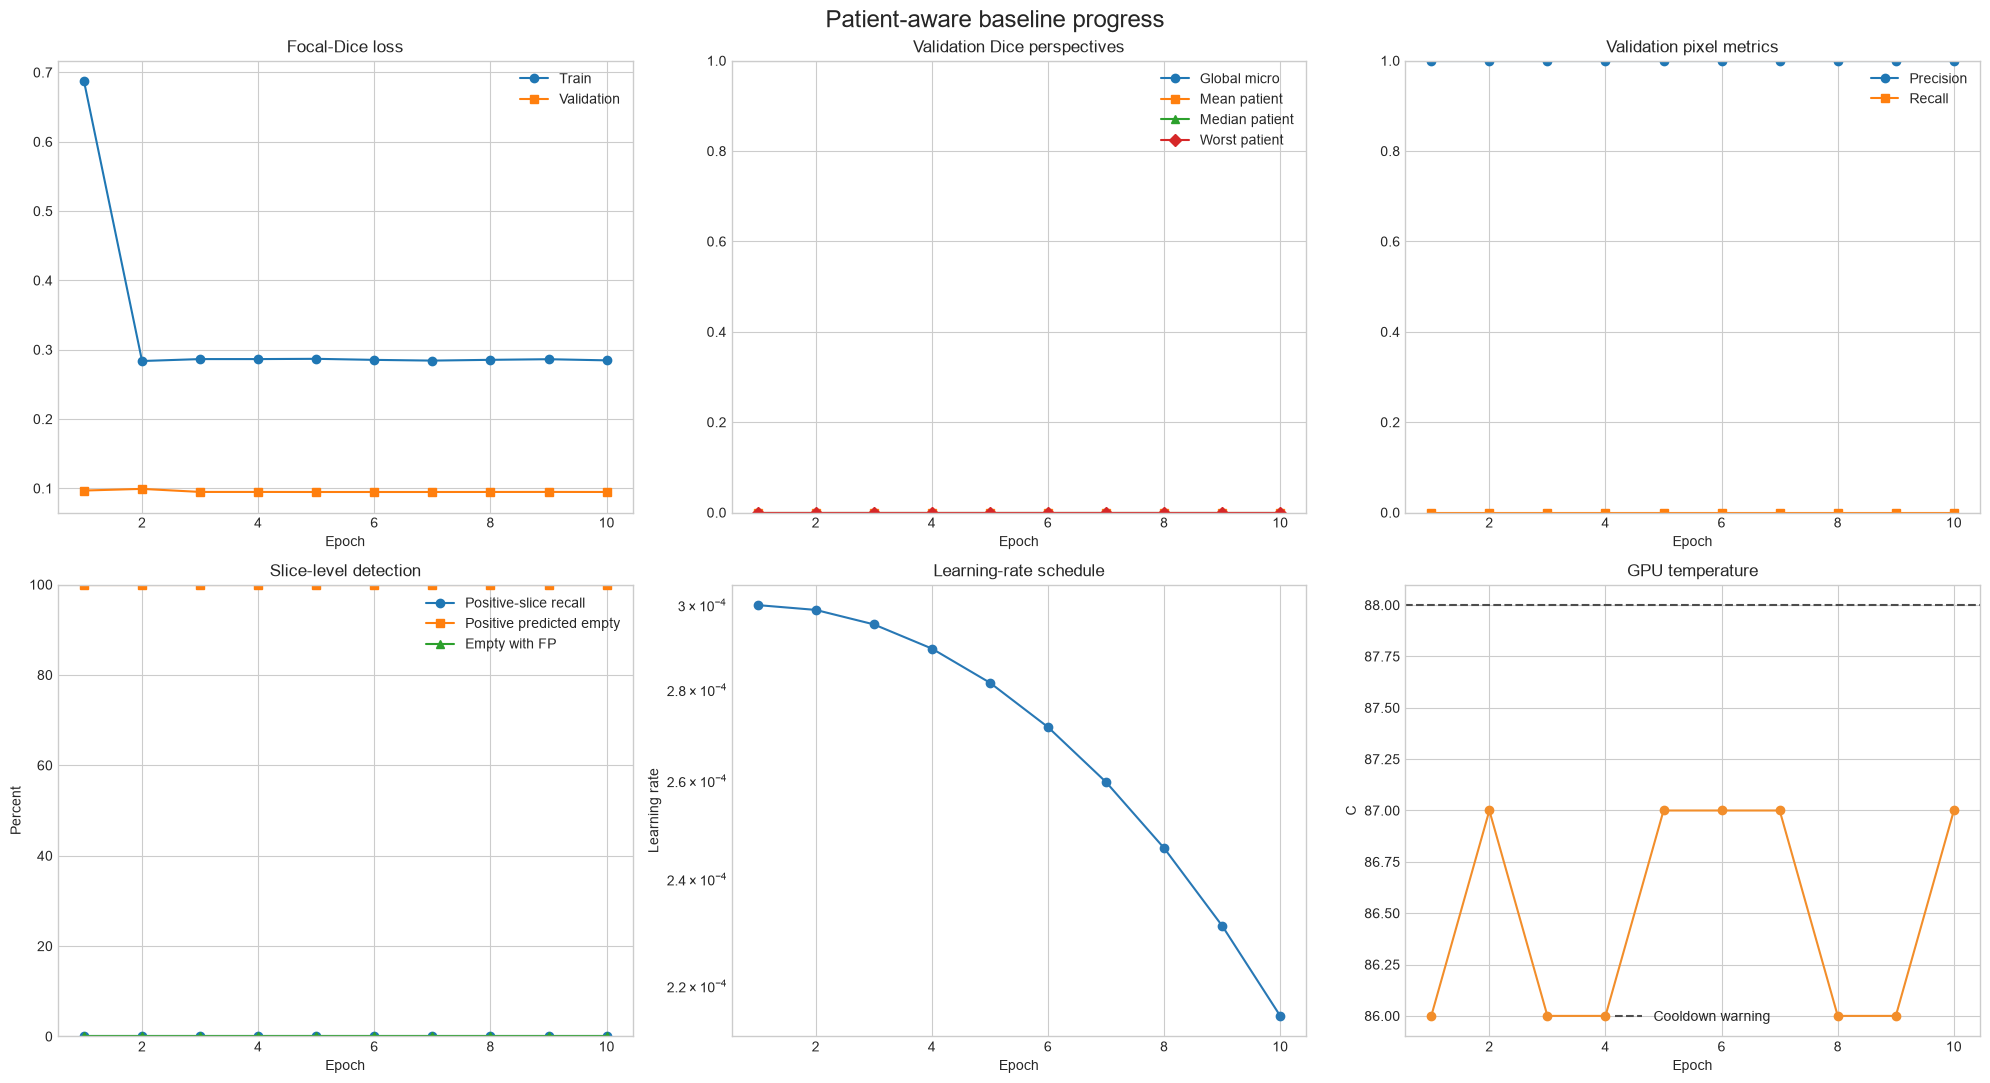

In [9]:
if history_frame.empty:
    print("No history available yet.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    axes[0, 0].plot(history_frame["epoch"], history_frame["train_loss"], marker="o", label="Train")
    axes[0, 0].plot(history_frame["epoch"], history_frame["val_loss"], marker="s", label="Validation")
    axes[0, 0].set_title("Focal-Dice loss"); axes[0, 0].set_xlabel("Epoch"); axes[0, 0].legend()

    for metric, label, marker in [
        ("val_global_micro_dice", "Global micro", "o"),
        ("val_mean_patient_dice", "Mean patient", "s"),
        ("val_median_patient_dice", "Median patient", "^"),
        ("val_worst_patient_dice", "Worst patient", "D"),
    ]:
        axes[0, 1].plot(history_frame["epoch"], history_frame[metric], marker=marker, label=label)
    axes[0, 1].set_ylim(0, 1); axes[0, 1].set_title("Validation Dice perspectives")
    axes[0, 1].set_xlabel("Epoch"); axes[0, 1].legend()

    axes[0, 2].plot(history_frame["epoch"], history_frame["val_pixel_precision"], marker="o", label="Precision")
    axes[0, 2].plot(history_frame["epoch"], history_frame["val_pixel_recall"], marker="s", label="Recall")
    axes[0, 2].set_ylim(0, 1); axes[0, 2].set_title("Validation pixel metrics")
    axes[0, 2].set_xlabel("Epoch"); axes[0, 2].legend()

    axes[1, 0].plot(history_frame["epoch"], 100 * history_frame["val_positive_slice_recall"], marker="o", label="Positive-slice recall")
    axes[1, 0].plot(history_frame["epoch"], history_frame["val_positive_predicted_empty_pct"], marker="s", label="Positive predicted empty")
    axes[1, 0].plot(history_frame["epoch"], history_frame["val_empty_slice_false_positive_pct"], marker="^", label="Empty with FP")
    axes[1, 0].set_ylim(0, 100); axes[1, 0].set_title("Slice-level detection")
    axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Percent"); axes[1, 0].legend()

    axes[1, 1].plot(history_frame["epoch"], history_frame["lr"], marker="o", color="#2878B5")
    axes[1, 1].set_yscale("log"); axes[1, 1].set_title("Learning-rate schedule")
    axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Learning rate")

    axes[1, 2].plot(history_frame["epoch"], history_frame["temperature_c"], marker="o", color="#F28E2B")
    axes[1, 2].axhline(COOLDOWN_WARNING_TEMP_C, linestyle="--", color="#4D4D4D", label="Cooldown warning")
    axes[1, 2].set_title("GPU temperature"); axes[1, 2].set_xlabel("Epoch")
    axes[1, 2].set_ylabel("C"); axes[1, 2].legend()

    fig.suptitle("Patient-aware baseline progress", fontsize=17)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "patient_aware_progress.png", dpi=160, bbox_inches="tight")
    plt.show()

### 8. Plot patient Dice trajectories and checkpoint-selection heatmap

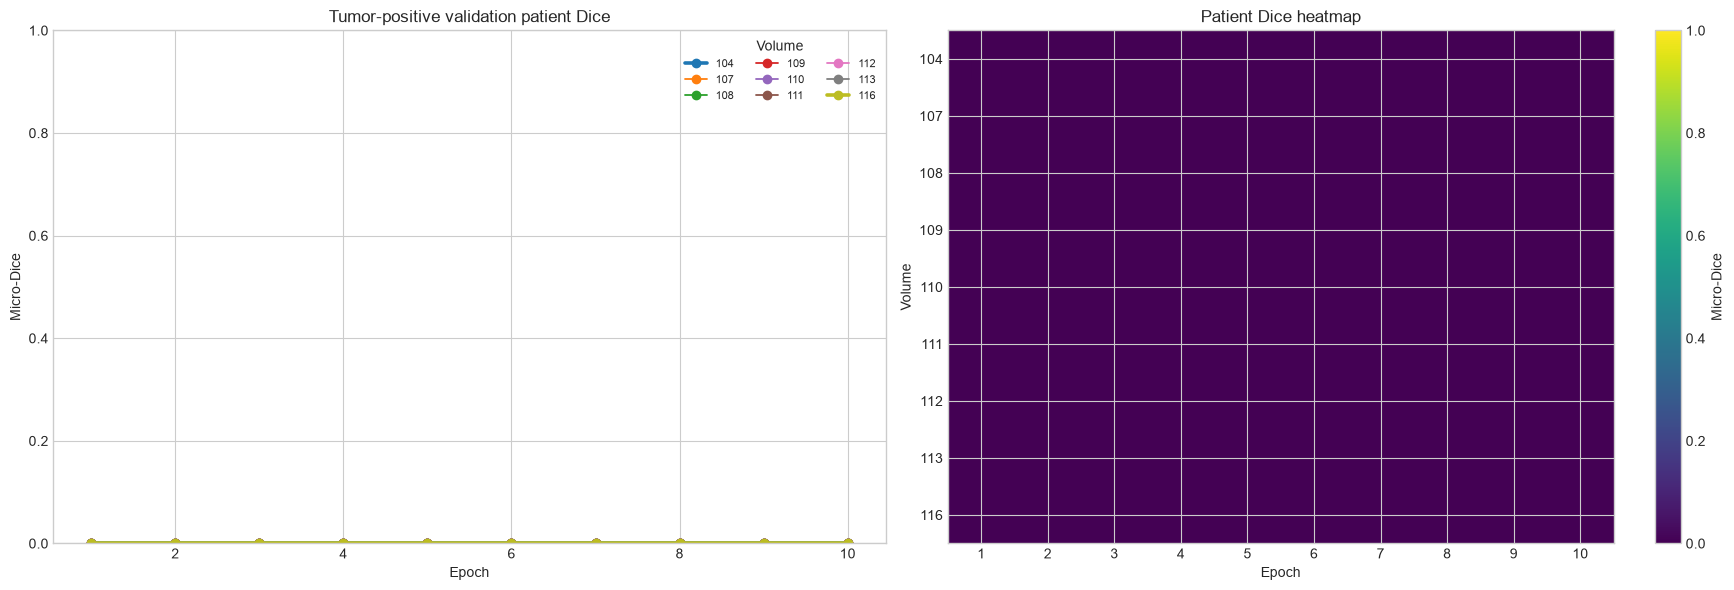

In [10]:
if patient_history_frame.empty:
    print("Patient history is unavailable.")
else:
    positive_patient_history = patient_history_frame.loc[
        patient_history_frame["true_pixels"].gt(0)
    ].copy()
    matrix = positive_patient_history.pivot(
        index="volume_id", columns="epoch", values="micro_dice"
    ).sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    for volume_id, group in positive_patient_history.groupby("volume_id"):
        linewidth = 2.6 if volume_id in {104, 116} else 1.3
        axes[0].plot(group["epoch"], group["micro_dice"], marker="o", linewidth=linewidth, label=str(volume_id))
    axes[0].set_ylim(0, 1); axes[0].set_title("Tumor-positive validation patient Dice")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Micro-Dice")
    axes[0].legend(title="Volume", ncol=3, fontsize=8)

    image = axes[1].imshow(matrix.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="viridis")
    axes[1].set_title("Patient Dice heatmap")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Volume")
    axes[1].set_xticks(range(len(matrix.columns)), matrix.columns)
    axes[1].set_yticks(range(len(matrix.index)), matrix.index)
    fig.colorbar(image, ax=axes[1], label="Micro-Dice")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "patient_dice_trajectories.png", dpi=160, bbox_inches="tight")
    plt.show()

### 9. Evaluate the best checkpoint, size quartiles, and threshold sensitivity

,value
best_epoch,1.000000e+00
loss,9.684274e-02
global_micro_dice,1.516330e-12
pixel_precision,1.000000e+00
pixel_recall,1.516330e-12
positive_slice_recall,0.000000e+00
positive_predicted_empty_pct,1.000000e+02
empty_slice_false_positive_pct,0.000000e+00
mean_patient_dice,5.303859e-10
median_patient_dice,4.744733e-11


,volume_id,micro_dice,true_pixels,predicted_pixels,positive_slices,positive_slice_recall,positive_predicted_empty_pct,empty_slice_false_positive_pct
0,104,1.448604e-11,69032,0,122,0.0,100.0,0.0
1,105,1.000000e+00,0,0,0,0.0,0.0,0.0
2,106,1.000000e+00,0,0,0,0.0,0.0,0.0
3,107,6.788866e-10,1473,0,71,0.0,100.0,0.0
4,108,2.749534e-12,363698,0,202,0.0,100.0,0.0
5,109,5.494505e-11,18200,0,131,0.0,100.0,0.0
6,110,3.213368e-11,31120,0,130,0.0,100.0,0.0
7,111,5.464481e-10,1830,0,92,0.0,100.0,0.0
8,112,3.389830e-09,295,0,26,0.0,100.0,0.0
9,113,4.744733e-11,21076,0,135,0.0,100.0,0.0


,size_quartile,slices,mean_dice,median_dice,detected_pct,predicted_empty_pct
0,Q1 smallest,263,1.327841e-07,7.142857e-08,0.0,100.0
1,Q2,258,1.146868e-08,9.216786e-09,0.0,100.0
2,Q3,260,2.735294e-09,2.710027e-09,0.0,100.0
3,Q4 largest,261,5.761557e-10,5.170631e-10,0.0,100.0


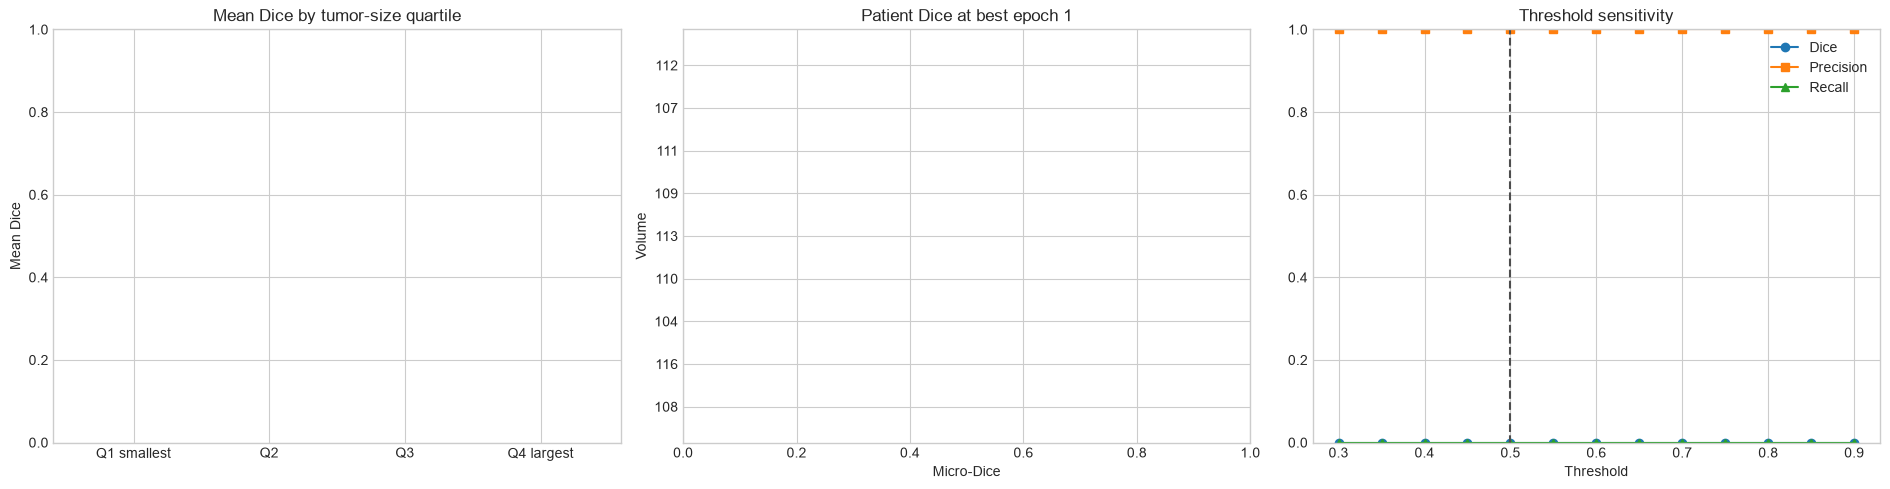

In [11]:
best_per_slice = pd.DataFrame()
best_patient_metrics = pd.DataFrame()
threshold_table = pd.DataFrame()
size_metrics = pd.DataFrame()

if best_checkpoint.is_file():
    best_payload = torch.load(best_checkpoint, map_location=device, weights_only=False)
    model.load_state_dict(best_payload["model_state"])
    best_epoch = int(best_payload["epoch"])
    final_result = evaluate_patient_aware(
        model, val_loader, criterion, device, FIXED_THRESHOLD, collect_rows=True
    )
    best_per_slice = pd.DataFrame(final_result.pop("rows"))
    best_patient_metrics = pd.DataFrame(final_result.pop("patient_rows"))
    best_per_slice.to_csv(OUTPUT_DIR / "best_validation_per_slice.csv", index=False)
    best_patient_metrics.to_csv(OUTPUT_DIR / "best_validation_patient_metrics.csv", index=False)

    positive_rows = best_per_slice.loc[best_per_slice["true_pixels"].gt(0)].copy()
    positive_rows["size_quartile"] = pd.qcut(
        positive_rows["true_pixels"], q=4,
        labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"],
        duplicates="drop",
    )
    size_metrics = (
        positive_rows.groupby("size_quartile", observed=True)
        .agg(
            slices=("sample_id", "size"), mean_dice=("dice", "mean"),
            median_dice=("dice", "median"),
            detected_pct=("intersection_pixels", lambda x: 100 * (x > 0).mean()),
            predicted_empty_pct=("predicted_pixels", lambda x: 100 * (x == 0).mean()),
        )
        .reset_index()
    )
    size_metrics.to_csv(OUTPUT_DIR / "best_validation_size_quartiles.csv", index=False)
    display(pd.DataFrame([{"best_epoch": best_epoch, **final_result}]).T.rename(columns={0: "value"}))
    display(best_patient_metrics)
    display(size_metrics)

    accumulators = {
        float(t): {"intersection": 0, "predicted": 0, "actual": 0} for t in THRESHOLDS
    }
    model.eval()
    with torch.inference_mode():
        for batch in val_loader:
            images = batch["image"].to(device, non_blocking=True)
            truth = batch["mask"].to(device, non_blocking=True) >= 0.5
            probabilities = torch.sigmoid(model(images))
            for threshold, acc in accumulators.items():
                prediction = probabilities >= threshold
                acc["intersection"] += int((prediction & truth).sum())
                acc["predicted"] += int(prediction.sum())
                acc["actual"] += int(truth.sum())
    threshold_table = pd.DataFrame([
        {
            "threshold": threshold,
            "micro_dice": (2 * acc["intersection"] + 1e-6) / (acc["predicted"] + acc["actual"] + 1e-6),
            "precision": (acc["intersection"] + 1e-6) / (acc["predicted"] + 1e-6),
            "recall": (acc["intersection"] + 1e-6) / (acc["actual"] + 1e-6),
        }
        for threshold, acc in accumulators.items()
    ])
    threshold_table.to_csv(OUTPUT_DIR / "best_validation_threshold_sweep.csv", index=False)

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    axes[0].bar(size_metrics["size_quartile"].astype(str), size_metrics["mean_dice"], color="#2878B5")
    axes[0].set_ylim(0, 1); axes[0].set_title("Mean Dice by tumor-size quartile")
    axes[0].set_xlabel(""); axes[0].set_ylabel("Mean Dice")

    positive_patients = best_patient_metrics.loc[best_patient_metrics["true_pixels"].gt(0)].sort_values("micro_dice")
    axes[1].barh(positive_patients["volume_id"].astype(str), positive_patients["micro_dice"], color="#F28E2B")
    axes[1].set_xlim(0, 1); axes[1].set_title(f"Patient Dice at best epoch {best_epoch}")
    axes[1].set_xlabel("Micro-Dice"); axes[1].set_ylabel("Volume")

    axes[2].plot(threshold_table["threshold"], threshold_table["micro_dice"], marker="o", label="Dice")
    axes[2].plot(threshold_table["threshold"], threshold_table["precision"], marker="s", label="Precision")
    axes[2].plot(threshold_table["threshold"], threshold_table["recall"], marker="^", label="Recall")
    axes[2].axvline(FIXED_THRESHOLD, linestyle="--", color="#4D4D4D")
    axes[2].set_ylim(0, 1); axes[2].set_title("Threshold sensitivity")
    axes[2].set_xlabel("Threshold"); axes[2].legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "best_model_diagnostics.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Best checkpoint unavailable; run training first.")

### 10. Visualize worst, best, and key-patient predictions

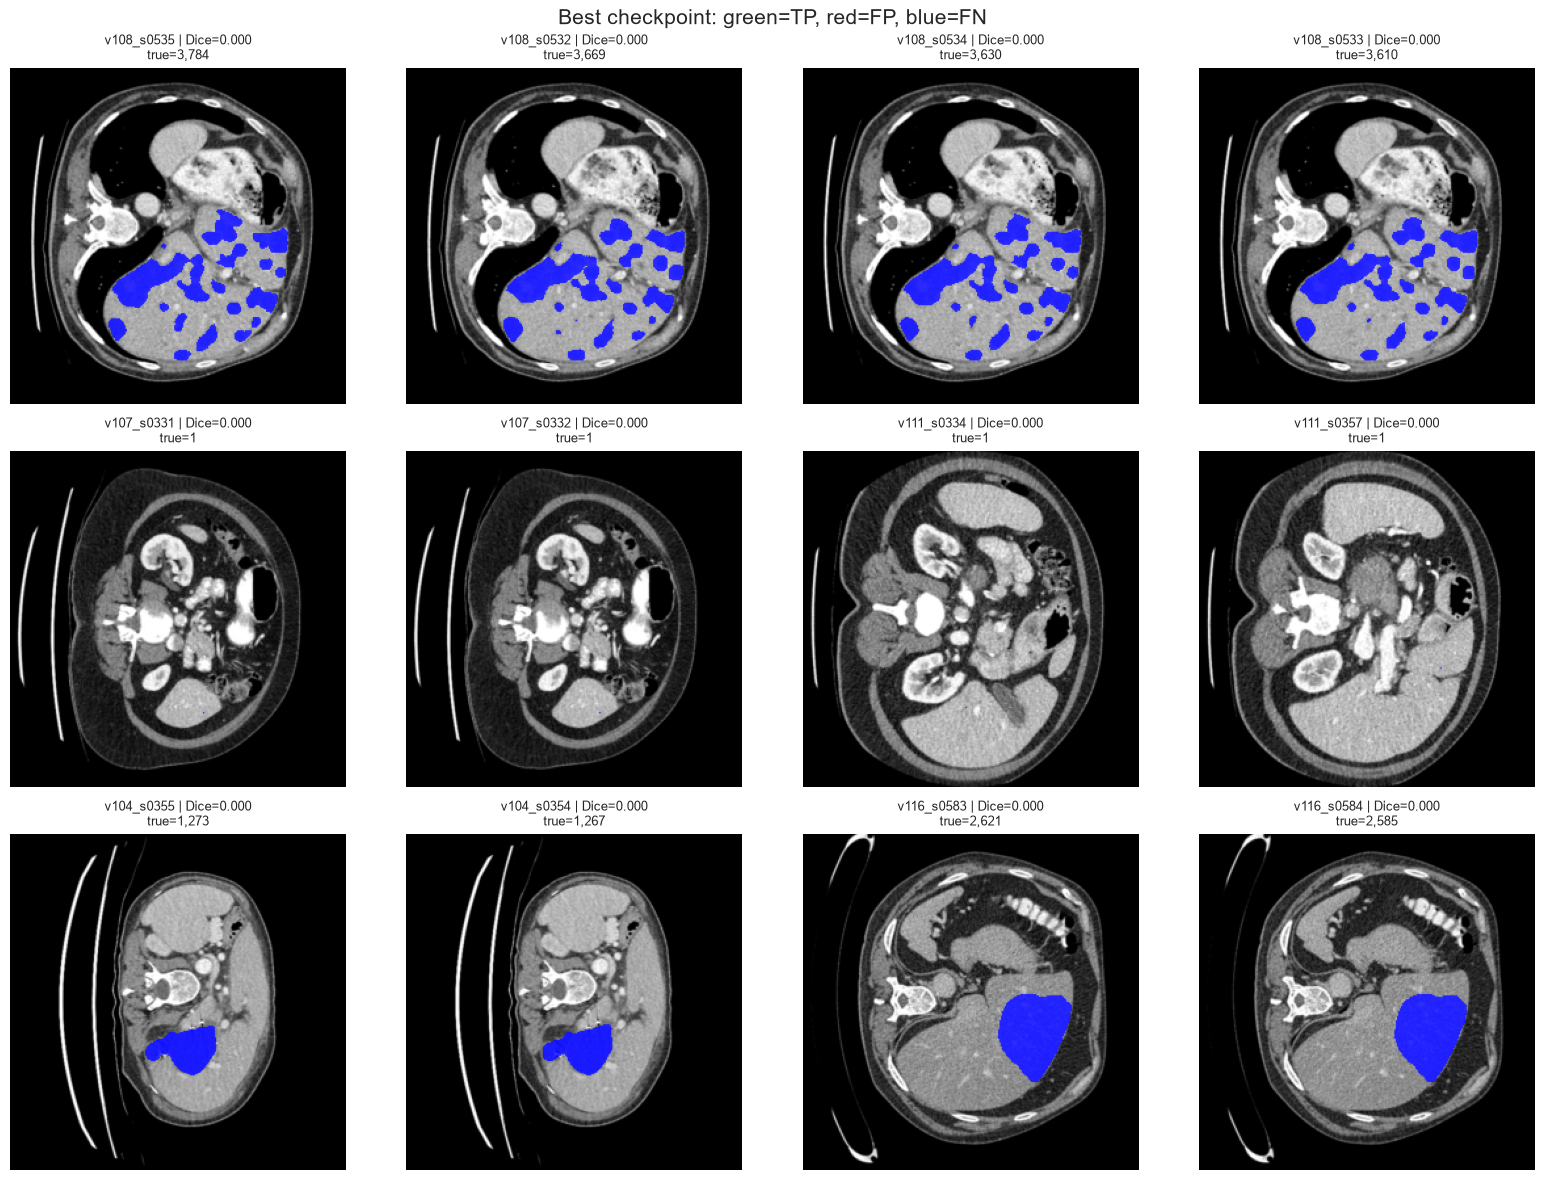

In [12]:
if not best_per_slice.empty:
    positive_rows = best_per_slice.loc[best_per_slice["true_pixels"].gt(0)]
    review_ids = []
    review_ids += positive_rows.nsmallest(4, "dice")["sample_id"].tolist()
    review_ids += positive_rows.nlargest(4, "dice")["sample_id"].tolist()
    for volume_id in [104, 116]:
        candidates = positive_rows.loc[positive_rows["volume_id"].eq(volume_id)]
        if len(candidates):
            review_ids += candidates.nlargest(2, "true_pixels")["sample_id"].tolist()
    review_ids = list(dict.fromkeys(review_ids))[:12]

    review_dataset = VerifiedManifestDataset(
        MANIFEST_PATH, split="val", root_dir=DATASET_ROOT,
        target="tumor", sample_ids=review_ids,
    )
    review_loader = DataLoader(review_dataset, batch_size=4, shuffle=False, num_workers=0)
    probabilities_by_id = {}
    model.eval()
    with torch.inference_mode():
        for batch in review_loader:
            probabilities = torch.sigmoid(model(batch["image"].to(device))).cpu().numpy()
            for index, sample_id in enumerate(batch["sample_id"]):
                probabilities_by_id[sample_id] = probabilities[index, 0]

    rows_count = math.ceil(len(review_dataset) / 4)
    fig, axes = plt.subplots(rows_count, 4, figsize=(16, 4 * rows_count))
    axes = np.atleast_1d(axes).ravel()
    for axis, item in zip(axes, review_dataset):
        sample_id = item["sample_id"]
        image = item["image"][0].numpy()
        truth = item["mask"][0].numpy().astype(bool)
        prediction = probabilities_by_id[sample_id] >= FIXED_THRESHOLD
        tp, fp, fn = prediction & truth, prediction & ~truth, truth & ~prediction
        rgb = np.repeat(image[..., None], 3, axis=2)
        rgb[tp, 1] = 1.0
        rgb[fp, 0] = 1.0; rgb[fp, 1:] *= 0.25
        rgb[fn, 2] = 1.0; rgb[fn, :2] *= 0.25
        row = best_per_slice.loc[best_per_slice["sample_id"].eq(sample_id)].iloc[0]
        axis.imshow(rgb)
        axis.set_title(f"{sample_id} | Dice={row['dice']:.3f}\ntrue={row['true_pixels']:,}", fontsize=9)
        axis.axis("off")
    for axis in axes[len(review_dataset):]:
        axis.axis("off")
    fig.suptitle("Best checkpoint: green=TP, red=FP, blue=FN", fontsize=15)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "best_model_prediction_errors.png", dpi=160, bbox_inches="tight")
    plt.show()

### Expanded process and error dashboard

The dashboard separates optimization progress, patient robustness, prediction
volume, false positives, confidence, and threshold behavior. It is regenerated
after every continuation session.

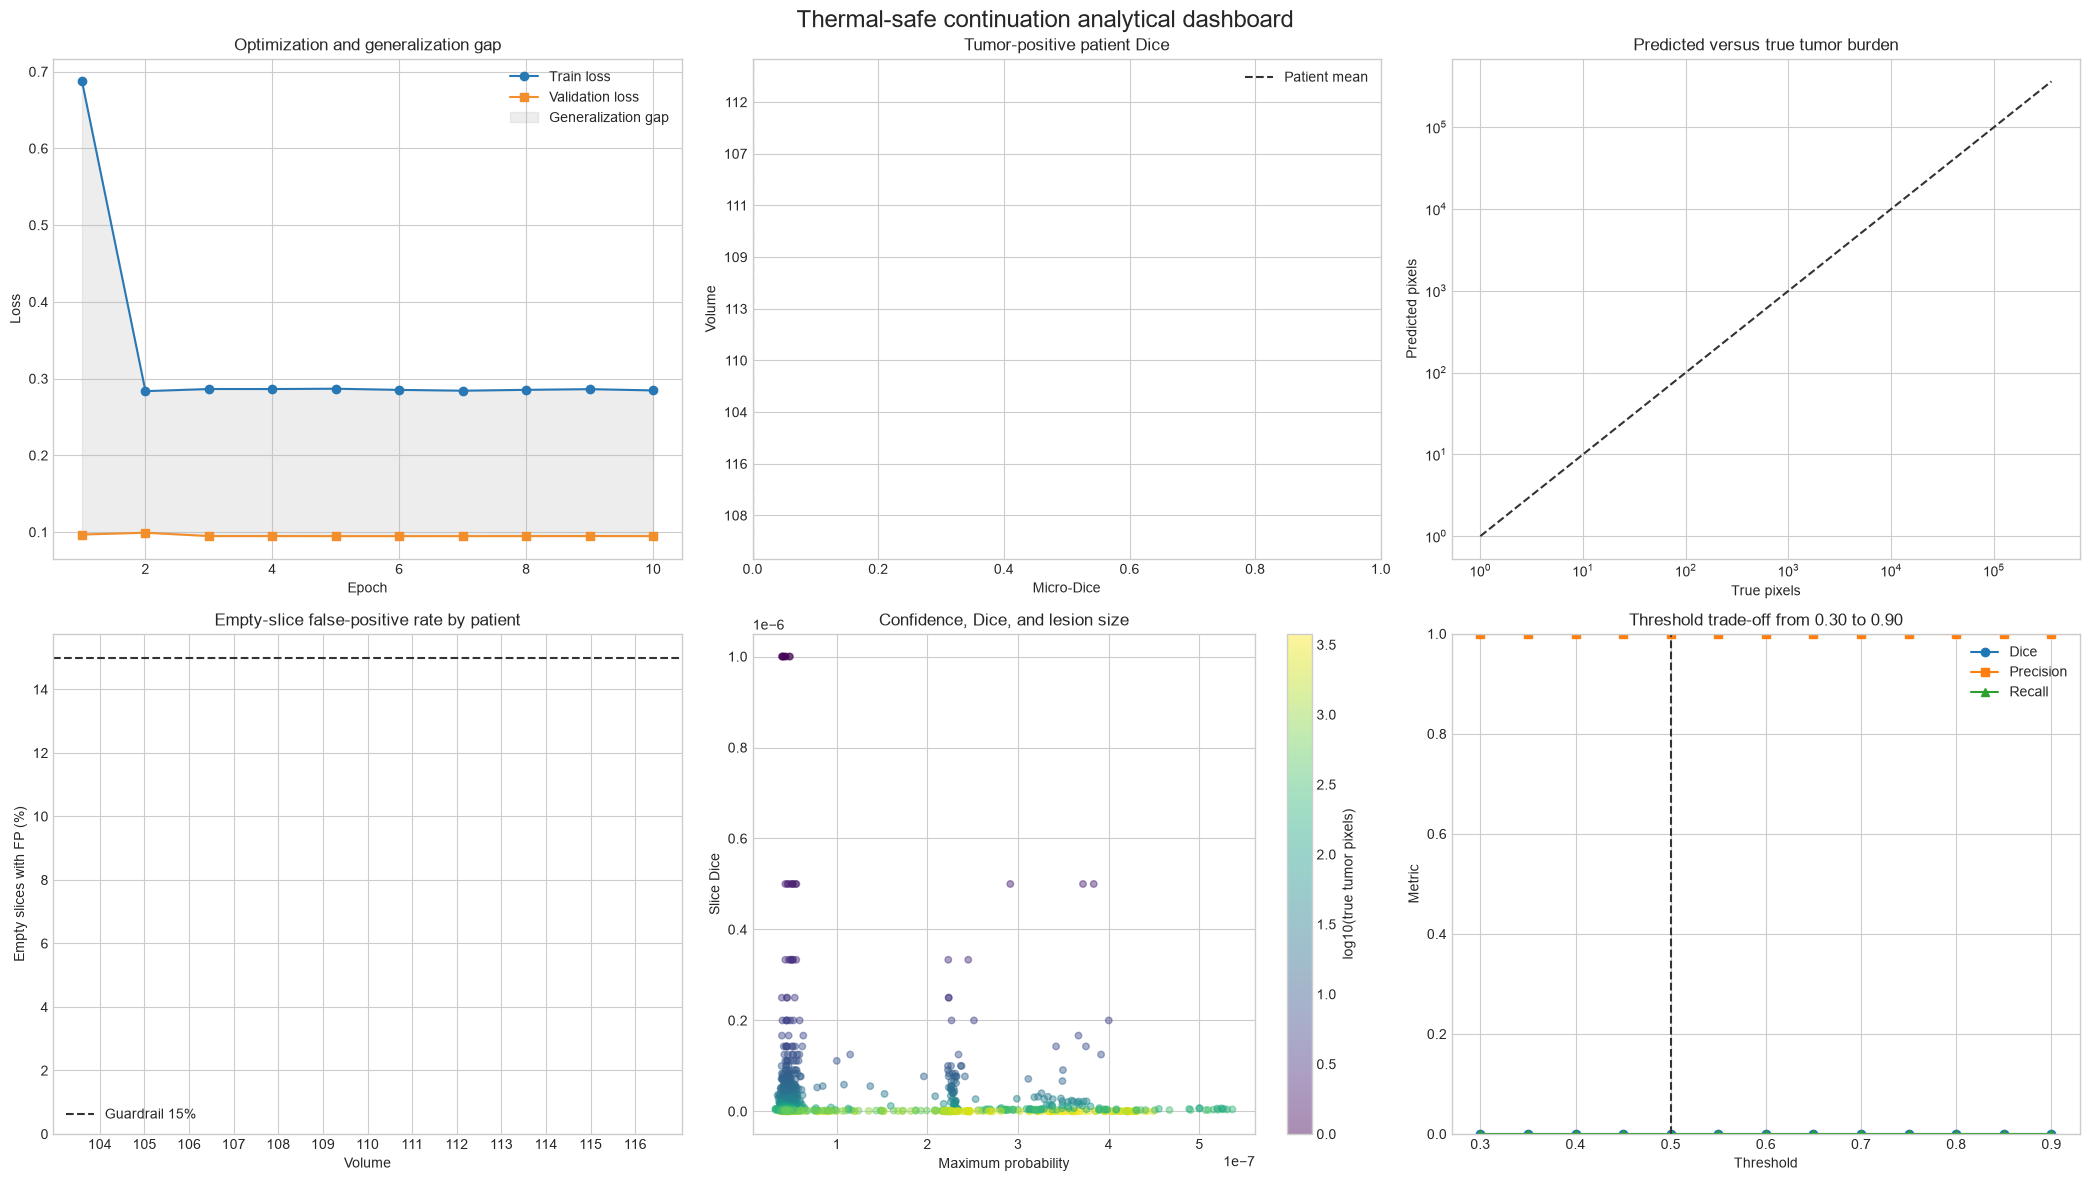

In [13]:

if history_frame.empty:
    print("Expanded dashboard is available after at least one completed epoch.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(21, 12))

    # 1. Generalization gap.
    axes[0, 0].plot(
        history_frame["epoch"], history_frame["train_loss"],
        marker="o", label="Train loss", color="#2878B5"
    )
    axes[0, 0].plot(
        history_frame["epoch"], history_frame["val_loss"],
        marker="s", label="Validation loss", color="#F28E2B"
    )
    axes[0, 0].fill_between(
        history_frame["epoch"],
        history_frame["train_loss"],
        history_frame["val_loss"],
        color="#B8B8B8", alpha=0.25, label="Generalization gap",
    )
    axes[0, 0].set_title("Optimization and generalization gap")
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    # 2. Patient distribution at the current best epoch.
    if not best_patient_metrics.empty:
        positive_patients = best_patient_metrics.loc[
            best_patient_metrics["true_pixels"].gt(0)
        ].sort_values("micro_dice")
        colors = [
            "#E15759" if volume in {104, 116} else "#2878B5"
            for volume in positive_patients["volume_id"]
        ]
        axes[0, 1].barh(
            positive_patients["volume_id"].astype(str),
            positive_patients["micro_dice"], color=colors
        )
        axes[0, 1].axvline(
            positive_patients["micro_dice"].mean(),
            linestyle="--", color="#333333", label="Patient mean"
        )
        axes[0, 1].set_xlim(0, 1)
        axes[0, 1].set_title("Tumor-positive patient Dice")
        axes[0, 1].set_xlabel("Micro-Dice"); axes[0, 1].set_ylabel("Volume")
        axes[0, 1].legend()

        # 3. Predicted versus true burden by patient.
        max_pixels = max(
            positive_patients["true_pixels"].max(),
            positive_patients["predicted_pixels"].max(),
        )
        axes[0, 2].scatter(
            positive_patients["true_pixels"],
            positive_patients["predicted_pixels"],
            s=80, color="#76B7B2", edgecolor="#333333"
        )
        axes[0, 2].plot([1, max_pixels], [1, max_pixels], linestyle="--", color="#333333")
        for row in positive_patients.itertuples(index=False):
            axes[0, 2].annotate(
                str(row.volume_id), (row.true_pixels, row.predicted_pixels),
                xytext=(4, 4), textcoords="offset points", fontsize=8
            )
        axes[0, 2].set_xscale("log"); axes[0, 2].set_yscale("log")
        axes[0, 2].set_title("Predicted versus true tumor burden")
        axes[0, 2].set_xlabel("True pixels"); axes[0, 2].set_ylabel("Predicted pixels")

        # 4. False-positive rate for every patient.
        fp_sorted = best_patient_metrics.sort_values(
            "empty_slice_false_positive_pct", ascending=False
        )
        axes[1, 0].bar(
            fp_sorted["volume_id"].astype(str),
            fp_sorted["empty_slice_false_positive_pct"],
            color="#E15759",
        )
        axes[1, 0].axhline(15, linestyle="--", color="#333333", label="Guardrail 15%")
        axes[1, 0].set_title("Empty-slice false-positive rate by patient")
        axes[1, 0].set_xlabel("Volume"); axes[1, 0].set_ylabel("Empty slices with FP (%)")
        axes[1, 0].legend()

    # 5. Confidence versus Dice on tumor-positive slices.
    if not best_per_slice.empty:
        positive_slices = best_per_slice.loc[best_per_slice["true_pixels"].gt(0)]
        scatter = axes[1, 1].scatter(
            positive_slices["max_probability"], positive_slices["dice"],
            c=np.log10(positive_slices["true_pixels"].clip(lower=1)),
            cmap="viridis", alpha=0.45, s=22,
        )
        axes[1, 1].set_title("Confidence, Dice, and lesion size")
        axes[1, 1].set_xlabel("Maximum probability"); axes[1, 1].set_ylabel("Slice Dice")
        fig.colorbar(scatter, ax=axes[1, 1], label="log10(true tumor pixels)")

    # 6. Extended threshold trade-off.
    if not threshold_table.empty:
        axes[1, 2].plot(
            threshold_table["threshold"], threshold_table["micro_dice"],
            marker="o", label="Dice"
        )
        axes[1, 2].plot(
            threshold_table["threshold"], threshold_table["precision"],
            marker="s", label="Precision"
        )
        axes[1, 2].plot(
            threshold_table["threshold"], threshold_table["recall"],
            marker="^", label="Recall"
        )
        axes[1, 2].axvline(FIXED_THRESHOLD, linestyle="--", color="#333333")
        axes[1, 2].set_ylim(0, 1)
        axes[1, 2].set_title("Threshold trade-off from 0.30 to 0.90")
        axes[1, 2].set_xlabel("Threshold"); axes[1, 2].set_ylabel("Metric")
        axes[1, 2].legend()

    fig.suptitle("Thermal-safe continuation analytical dashboard", fontsize=17)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "continuation_expanded_dashboard.png", dpi=160, bbox_inches="tight")
    plt.show()


### Thermal cooldown profile

This graph shows how long the GPU waited before each epoch and whether cooling
behavior is stable across the continuation run.

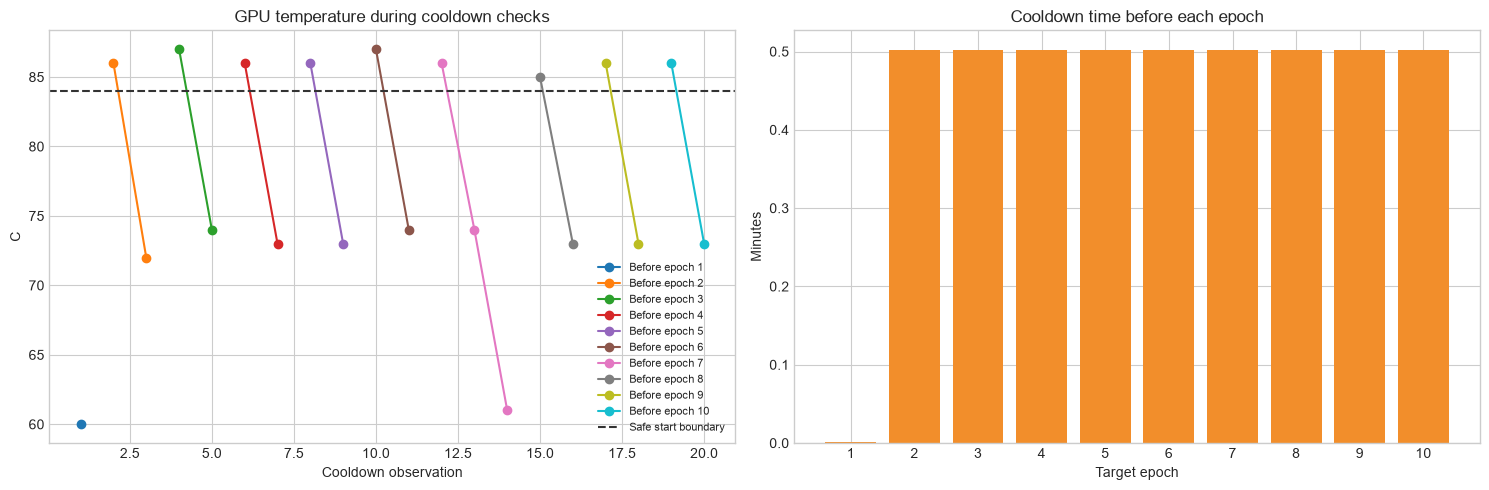

In [14]:

thermal_log_path = OUTPUT_DIR / "thermal_cooldown_log.csv"
if thermal_log_path.is_file():
    thermal_log = pd.read_csv(thermal_log_path)
    thermal_log["sequence"] = np.arange(1, len(thermal_log) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    for epoch, group in thermal_log.groupby("target_epoch"):
        axes[0].plot(
            group["sequence"], group["temperature_c"],
            marker="o", label=f"Before epoch {epoch}"
        )
    axes[0].axhline(
        MAX_START_GPU_TEMP_C, linestyle="--", color="#333333",
        label="Safe start boundary"
    )
    axes[0].set_title("GPU temperature during cooldown checks")
    axes[0].set_xlabel("Cooldown observation"); axes[0].set_ylabel("C")
    axes[0].legend(fontsize=8)

    final_wait = (
        thermal_log.groupby("target_epoch")["cooldown_elapsed_seconds"]
        .max().reset_index()
    )
    axes[1].bar(
        final_wait["target_epoch"].astype(str),
        final_wait["cooldown_elapsed_seconds"] / 60,
        color="#F28E2B",
    )
    axes[1].set_title("Cooldown time before each epoch")
    axes[1].set_xlabel("Target epoch"); axes[1].set_ylabel("Minutes")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "thermal_cooldown_profile.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Thermal cooldown log will appear when continuation training starts.")


### Controlled loss comparison dashboard

Compare the recall-aware loss with the frozen Focal-Dice baseline and the
rejected balanced-sampler experiment using validation metrics only.


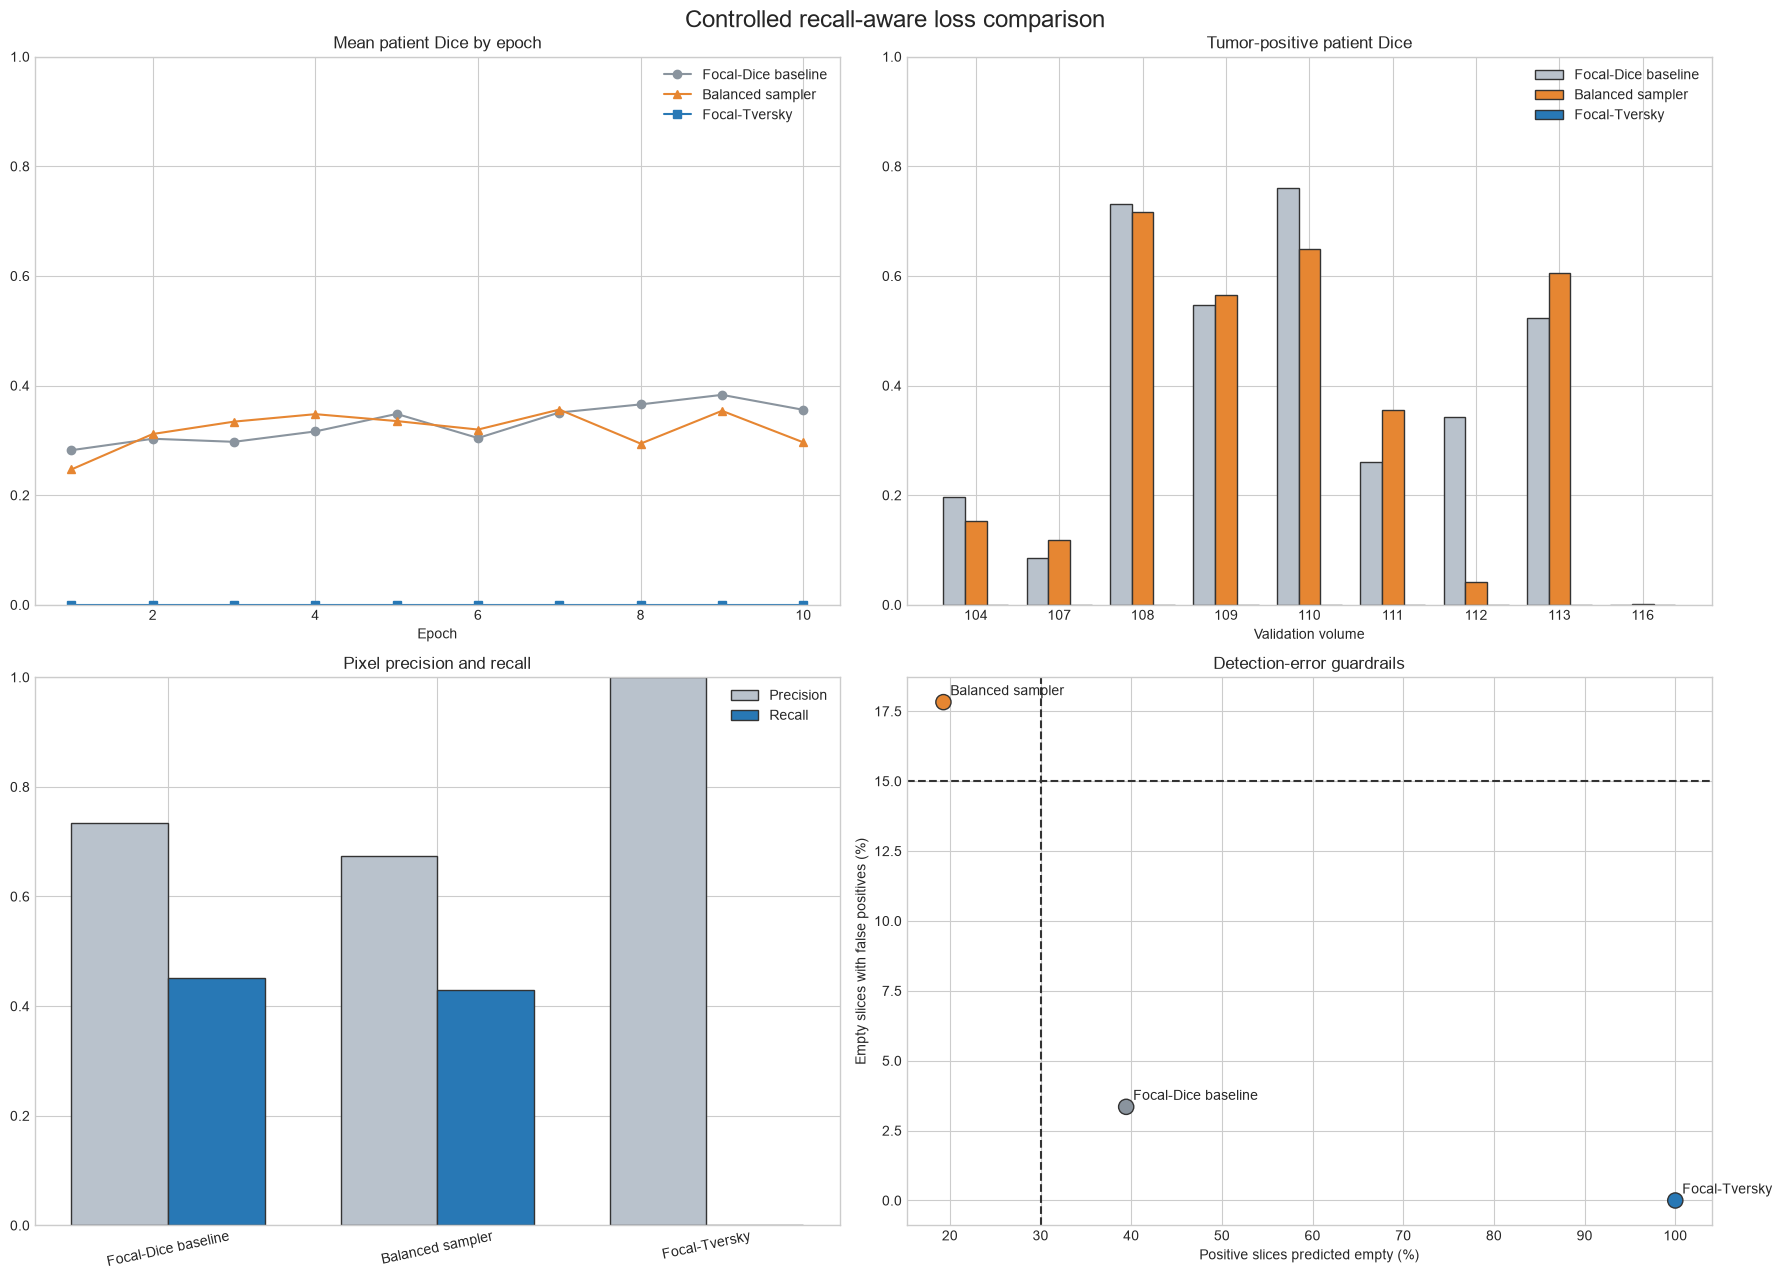

,experiment,mean_patient_dice,global_dice,precision,recall,positive_empty_pct,empty_fp_pct
0,Focal-Dice baseline,0.3831,0.5584,0.7335,0.4507,39.4434,3.3496
1,Balanced sampler,0.3562,0.5242,0.6734,0.4291,19.2898,17.8264
2,Focal-Tversky,0.0000,0.0000,1.0000,0.0000,100.0000,0.0000


In [15]:
baseline_history = pd.read_csv(
    BASELINE_OUTPUT_DIR / "patient_aware_history.csv"
)
sampler_history = pd.read_csv(
    SAMPLER_OUTPUT_DIR / "patient_aware_history.csv"
)
baseline_patients = pd.read_csv(
    BASELINE_OUTPUT_DIR / "best_validation_patient_metrics.csv"
)
sampler_patients = pd.read_csv(
    SAMPLER_OUTPUT_DIR / "best_validation_patient_metrics.csv"
)

if not history_frame.empty and not best_patient_metrics.empty:
    baseline_best = baseline_history.loc[baseline_history["val_mean_patient_dice"].idxmax()]
    sampler_best = sampler_history.loc[sampler_history["val_mean_patient_dice"].idxmax()]
    loss_best = history_frame.loc[history_frame["val_mean_patient_dice"].idxmax()]
    experiments = {
        "Focal-Dice baseline": baseline_best,
        "Balanced sampler": sampler_best,
        "Focal-Tversky": loss_best,
    }
    comparison = pd.DataFrame([
        {
            "experiment": name,
            "mean_patient_dice": row["val_mean_patient_dice"],
            "global_dice": row["val_global_micro_dice"],
            "precision": row["val_pixel_precision"],
            "recall": row["val_pixel_recall"],
            "positive_empty_pct": row["val_positive_predicted_empty_pct"],
            "empty_fp_pct": row["val_empty_slice_false_positive_pct"],
        }
        for name, row in experiments.items()
    ])

    patient_comparison = (
        baseline_patients[["volume_id", "micro_dice"]]
        .rename(columns={"micro_dice": "Focal-Dice baseline"})
        .merge(
            sampler_patients[["volume_id", "micro_dice"]].rename(
                columns={"micro_dice": "Balanced sampler"}
            ), on="volume_id",
        )
        .merge(
            best_patient_metrics[["volume_id", "micro_dice"]].rename(
                columns={"micro_dice": "Focal-Tversky"}
            ), on="volume_id",
        )
    )
    patient_comparison = patient_comparison.loc[
        patient_comparison["volume_id"].isin([104, 107, 108, 109, 110, 111, 112, 113, 116])
    ]

    fig, axes = plt.subplots(2, 2, figsize=(18, 13))
    for frame, label, marker, color in [
        (baseline_history, "Focal-Dice baseline", "o", "#8A949E"),
        (sampler_history, "Balanced sampler", "^", "#E68632"),
        (history_frame, "Focal-Tversky", "s", "#2878B5"),
    ]:
        axes[0, 0].plot(
            frame["epoch"], frame["val_mean_patient_dice"],
            marker=marker, color=color, label=label,
        )
    axes[0, 0].set_title("Mean patient Dice by epoch")
    axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylim(0, 1); axes[0, 0].legend()

    x = np.arange(len(patient_comparison))
    width = 0.26
    for offset, column, color in [
        (-width, "Focal-Dice baseline", "#B9C2CC"),
        (0, "Balanced sampler", "#E68632"),
        (width, "Focal-Tversky", "#2878B5"),
    ]:
        axes[0, 1].bar(
            x + offset, patient_comparison[column], width,
            label=column, color=color, edgecolor="#333333",
        )
    axes[0, 1].set_xticks(x, patient_comparison["volume_id"].astype(str))
    axes[0, 1].set_title("Tumor-positive patient Dice")
    axes[0, 1].set_xlabel("Validation volume"); axes[0, 1].set_ylim(0, 1)
    axes[0, 1].legend()

    metric_x = np.arange(len(comparison))
    axes[1, 0].bar(
        metric_x - 0.18, comparison["precision"], 0.36,
        label="Precision", color="#B9C2CC", edgecolor="#333333",
    )
    axes[1, 0].bar(
        metric_x + 0.18, comparison["recall"], 0.36,
        label="Recall", color="#2878B5", edgecolor="#333333",
    )
    axes[1, 0].set_xticks(metric_x, comparison["experiment"], rotation=12)
    axes[1, 0].set_title("Pixel precision and recall")
    axes[1, 0].set_ylim(0, 1); axes[1, 0].legend()

    axes[1, 1].scatter(
        comparison["positive_empty_pct"], comparison["empty_fp_pct"],
        s=120, color=["#8A949E", "#E68632", "#2878B5"], edgecolor="#333333",
    )
    for row in comparison.itertuples(index=False):
        axes[1, 1].annotate(
            row.experiment, (row.positive_empty_pct, row.empty_fp_pct),
            xytext=(5, 5), textcoords="offset points",
        )
    axes[1, 1].axvline(30, linestyle="--", color="#333333")
    axes[1, 1].axhline(15, linestyle="--", color="#333333")
    axes[1, 1].set_title("Detection-error guardrails")
    axes[1, 1].set_xlabel("Positive slices predicted empty (%)")
    axes[1, 1].set_ylabel("Empty slices with false positives (%)")

    fig.suptitle("Controlled recall-aware loss comparison", fontsize=17)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "loss_ablation_comparison_dashboard.png", dpi=160, bbox_inches="tight")
    plt.show()
    display(comparison.style.format({
        column: "{:.4f}" for column in comparison.columns if column != "experiment"
    }))
else:
    print("Comparison is available after training and best-checkpoint evaluation.")


## Takeaways

This is a controlled loss ablation. Promote Focal-Tversky only if it improves
mean patient Dice and patient 116 while keeping empty-slice false positives
below 15%. Global Dice alone is insufficient.


In [16]:
minimum_decision_epoch_reached = (
    not history_frame.empty
    and int(history_frame["epoch"].max()) >= MIN_EPOCHS_BEFORE_EARLY_STOP
)
baseline_gate = json.loads(
    (BASELINE_OUTPUT_DIR / "patient_aware_gate_result.json").read_text(encoding="utf-8")
)
sampler_gate = json.loads(
    (SAMPLER_OUTPUT_DIR / "sampler_ablation_gate_result.json").read_text(encoding="utf-8")
)

if not minimum_decision_epoch_reached:
    completed_epochs = int(history_frame["epoch"].max()) if not history_frame.empty else 0
    final_gate = {
        "status": "incomplete_continue_to_epoch_10",
        "epochs_completed": completed_epochs,
        "minimum_decision_epoch": MIN_EPOCHS_BEFORE_EARLY_STOP,
        "loss_strategy": LOSS_STRATEGY,
        "test_images_accessed": False,
        "decision": f"INCOMPLETE — continue from epoch {completed_epochs + 1}.",
    }
elif best_patient_metrics.empty or size_metrics.empty:
    final_gate = {
        "status": "not_run",
        "loss_strategy": LOSS_STRATEGY,
        "test_images_accessed": False,
        "decision": "Run training and best-checkpoint evaluation.",
    }
else:
    best_row = history_frame.loc[history_frame["val_mean_patient_dice"].idxmax()]
    positive_patients = best_patient_metrics.loc[best_patient_metrics["true_pixels"].gt(0)]
    volume_104 = positive_patients.loc[positive_patients["volume_id"].eq(104), "micro_dice"]
    volume_116 = positive_patients.loc[positive_patients["volume_id"].eq(116), "micro_dice"]
    q1 = size_metrics.loc[size_metrics["size_quartile"].eq("Q1 smallest")].iloc[0]

    mean_improved = float(best_row["val_mean_patient_dice"]) > float(
        baseline_gate["best_mean_patient_dice"]
    )
    volume_104_preserved = bool(
        len(volume_104)
        and float(volume_104.iloc[0]) >= float(baseline_gate["volume_104_dice"])
    )
    volume_116_recovered = bool(len(volume_116) and float(volume_116.iloc[0]) > 0.05)
    q1_detection_improved = float(q1["detected_pct"]) > 35.0
    guardrails = bool(
        float(best_row["val_positive_predicted_empty_pct"]) < 30.0
        and float(best_row["val_empty_slice_false_positive_pct"]) < 15.0
    )
    ready = all([
        mean_improved, volume_104_preserved, volume_116_recovered,
        q1_detection_improved, guardrails,
    ])
    final_gate = {
        "status": "recall_aware_loss_pass" if ready else "recall_aware_loss_fail",
        "manifest_sha256": manifest_hash,
        "sampler_strategy": SAMPLER_STRATEGY,
        "loss_strategy": LOSS_STRATEGY,
        "epochs_completed": int(history_frame["epoch"].max()),
        "best_epoch": int(best_row["epoch"]),
        "best_global_micro_dice": float(best_row["val_global_micro_dice"]),
        "best_mean_patient_dice": float(best_row["val_mean_patient_dice"]),
        "baseline_mean_patient_dice": float(baseline_gate["best_mean_patient_dice"]),
        "sampler_mean_patient_dice": float(sampler_gate["best_mean_patient_dice"]),
        "volume_104_dice": float(volume_104.iloc[0]) if len(volume_104) else None,
        "volume_116_dice": float(volume_116.iloc[0]) if len(volume_116) else None,
        "q1_smallest_detected_pct": float(q1["detected_pct"]),
        "positive_predicted_empty_pct": float(best_row["val_positive_predicted_empty_pct"]),
        "empty_slice_false_positive_pct": float(best_row["val_empty_slice_false_positive_pct"]),
        "mean_patient_improved": mean_improved,
        "volume_104_preserved": volume_104_preserved,
        "volume_116_recovered": volume_116_recovered,
        "q1_detection_improved": q1_detection_improved,
        "detection_guardrails_pass": guardrails,
        "test_images_accessed": False,
        "decision": (
            "PASS — retain Focal-Tversky and plan a longer confirmation run."
            if ready else
            "FAIL — retain the Focal-Dice baseline and investigate domain/appearance robustness."
        ),
    }

(OUTPUT_DIR / "recall_aware_loss_gate_result.json").write_text(
    json.dumps(final_gate, indent=2), encoding="utf-8"
)
display(pd.DataFrame([final_gate]).T.rename(columns={0: "result"}))
print(final_gate["decision"])


,result
status,recall_aware_loss_fail
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
sampler_strategy,positive_slice_weight_3_baseline
loss_strategy,focal_tversky_a040_b060_g075
epochs_completed,10
best_epoch,1
best_global_micro_dice,0.0
best_mean_patient_dice,0.0
baseline_mean_patient_dice,0.383069
sampler_mean_patient_dice,0.356189


FAIL — retain the Focal-Dice baseline and investigate domain/appearance robustness.


### Interpretation guide

- If patient mean improves and volumes 104/116 become nonzero, the longer
  baseline has addressed the main smoke-test failure.
- If global Dice rises while patient mean remains flat, the model is still
  dominated by high-burden patients.
- If volume 116 remains near zero after 10–15 epochs, stop and consider a
  liver-first or multitask liver/tumor strategy.
- If false positives rise, reduce positive sampling or strengthen negative
  exposure before changing the decision threshold.
- Threshold curves are diagnostic only. Do not touch the test split until the
  architecture, stopping rule, sampling, loss, and threshold-selection
  procedure are frozen.